<a href="https://colab.research.google.com/github/superv13/NLP_Assignment-02/blob/main/LSTM_GRUipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))

        out = self.fc(out[:, -1, :])

        return out

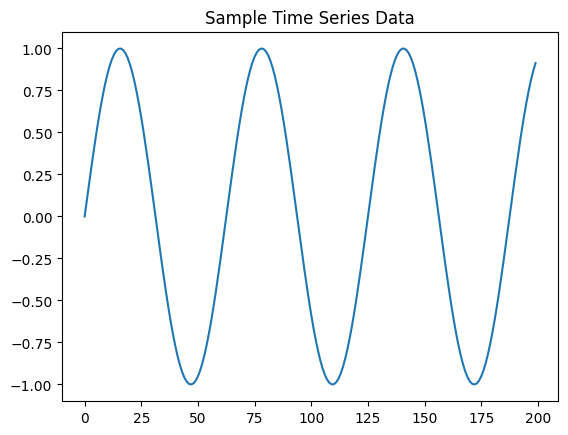

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate sample time series data

time_steps = 200
t = np.linspace(0, 20, time_steps)
data = np.sin(t)

plt.plot(data)
plt.title("Sample Time Series Data")
plt.show()

In [3]:
def create_sequences(data, seq_length):

    sequences = []
    targets = []

    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length]
        target = data[i+seq_length]

        sequences.append(seq)
        targets.append(target)

    return np.array(sequences), np.array(targets)


seq_length = 10

X, y = create_sequences(data, seq_length)

X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

print(X.shape)
print(y.shape)

torch.Size([190, 10, 1])
torch.Size([190, 1])


In [4]:
input_size = 1
hidden_size = 64
num_layers = 2
output_size = 1
learning_rate = 0.001
epochs = 100

In [5]:
model = LSTMModel(input_size, hidden_size, num_layers, output_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [6]:
for epoch in range(epochs):

    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.4247
Epoch [20/100], Loss: 0.2176
Epoch [30/100], Loss: 0.1569
Epoch [40/100], Loss: 0.1064
Epoch [50/100], Loss: 0.0709
Epoch [60/100], Loss: 0.0257
Epoch [70/100], Loss: 0.0116
Epoch [80/100], Loss: 0.0054
Epoch [90/100], Loss: 0.0050
Epoch [100/100], Loss: 0.0040


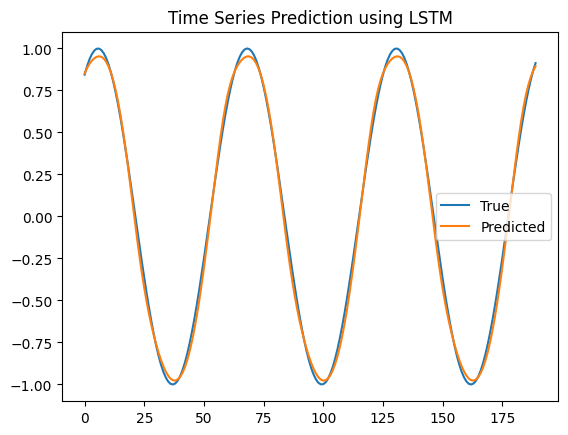

In [7]:
model.eval()

predicted = model(X).detach().numpy()

plt.plot(y.numpy(), label="True")
plt.plot(predicted, label="Predicted")
plt.legend()
plt.title("Time Series Prediction using LSTM")
plt.show()

In [8]:
import torch
import torch.nn as nn

class CustomGRU(nn.Module):

    def __init__(self, input_size, hidden_size):
        super(CustomGRU, self).__init__()

        self.hidden_size = hidden_size

        # Update gate parameters
        self.Wz = nn.Linear(input_size, hidden_size)
        self.Uz = nn.Linear(hidden_size, hidden_size)

        # Reset gate parameters
        self.Wr = nn.Linear(input_size, hidden_size)
        self.Ur = nn.Linear(hidden_size, hidden_size)

        # Candidate hidden state
        self.Wh = nn.Linear(input_size, hidden_size)
        self.Uh = nn.Linear(hidden_size, hidden_size)

        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()


    def forward(self, x):

        batch_size, seq_len, input_size = x.size()

        h = torch.zeros(batch_size, self.hidden_size)

        outputs = []

        for t in range(seq_len):

            xt = x[:, t, :]

            # Update Gate
            zt = self.sigmoid(self.Wz(xt) + self.Uz(h))

            # Reset Gate
            rt = self.sigmoid(self.Wr(xt) + self.Ur(h))

            # Candidate Hidden State
            h_tilde = self.tanh(self.Wh(xt) + self.Uh(rt * h))

            # Final Hidden State
            h = (1 - zt) * h + zt * h_tilde

            outputs.append(h.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)

        return outputs

In [ ]:
import torch
import torch.nn as nn

# Example input (tokenized sentence)
# each number represents a word index
sample_sentence = torch.tensor([[4, 15, 23, 7, 2]])

# pass through GRU
output = gru_model(sample_sentence)

# convert to probability
prob = torch.sigmoid(output)

print("Sentiment Score:", prob.item())

if prob > 0.5:
    print("Positive sentiment")
else:
    print("Negative sentiment")